# 1. Install & Load Libraries

In [1]:
if (!require(arules))     install.packages("arules",     repos="https://cran.r-project.org")
if (!require(arulesViz))  install.packages("arulesViz",  repos="https://cran.r-project.org")
if (!require(ggplot2))    install.packages("ggplot2",    repos="https://cran.r-project.org")

library(arules)
library(arulesViz)
library(ggplot2)

Loading required package: arules

Warning message in library(package, lib.loc = lib.loc, character.only = TRUE, logical.return = TRUE, :
“there is no package called ‘arules’”
Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Loading required package: arulesViz

Warning message in library(package, lib.loc = lib.loc, character.only = TRUE, logical.return = TRUE, :
“there is no package called ‘arulesViz’”
Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘tweenr’, ‘polyclip’, ‘gridExtra’, ‘RcppArmadillo’, ‘iterators’, ‘permute’, ‘zoo’, ‘crosstalk’, ‘ggforce’, ‘ggrepel’, ‘viridis’, ‘tidygraph’, ‘graphlayouts’, ‘lazyeval’, ‘ca’, ‘colorspace’, ‘foreach’, ‘gclus’, ‘qap’, ‘registry’, ‘TSP’, ‘vegan’, ‘lmtest’, ‘DT’, ‘ggraph’, ‘igraph’, ‘plotly’, ‘scatterplot3d’, ‘seriation’, ‘vcd’, ‘visNetwork’


Loading required package: ggplot2

Loading required package: Matrix


Attaching package: ‘arules’


Th

# 2. Load Groceries Dataset

In [2]:
data("Groceries")

cat("===== Dataset Summary =====\n")
summary(Groceries)

cat("\n===== First 5 Transactions =====\n")
inspect(Groceries[1:5])

cat("\n===== Dimensions =====\n")
cat("Transactions:", length(Groceries), "\n")
cat("Items:", ncol(Groceries), "\n")

===== Dataset Summary =====


transactions as itemMatrix in sparse format with
 9835 rows (elements/itemsets/transactions) and
 169 columns (items) and a density of 0.02609146 

most frequent items:
      whole milk other vegetables       rolls/buns             soda 
            2513             1903             1809             1715 
          yogurt          (Other) 
            1372            34055 

element (itemset/transaction) length distribution:
sizes
   1    2    3    4    5    6    7    8    9   10   11   12   13   14   15   16 
2159 1643 1299 1005  855  645  545  438  350  246  182  117   78   77   55   46 
  17   18   19   20   21   22   23   24   26   27   28   29   32 
  29   14   14    9   11    4    6    1    1    1    1    3    1 

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  1.000   2.000   3.000   4.409   6.000  32.000 

includes extended item information - examples:
       labels  level2           level1
1 frankfurter sausage meat and sausage
2     sausage sausage meat and sausage
3  live


===== First 5 Transactions =====
    items                     
[1] {citrus fruit,            
     semi-finished bread,     
     margarine,               
     ready soups}             
[2] {tropical fruit,          
     yogurt,                  
     coffee}                  
[3] {whole milk}              
[4] {pip fruit,               
     yogurt,                  
     cream cheese ,           
     meat spreads}            
[5] {other vegetables,        
     whole milk,              
     condensed milk,          
     long life bakery product}

===== Dimensions =====
Transactions: 9835 
Items: 169 


# 3. Explore Item Frequency


===== Top 10 Most Frequent Items =====


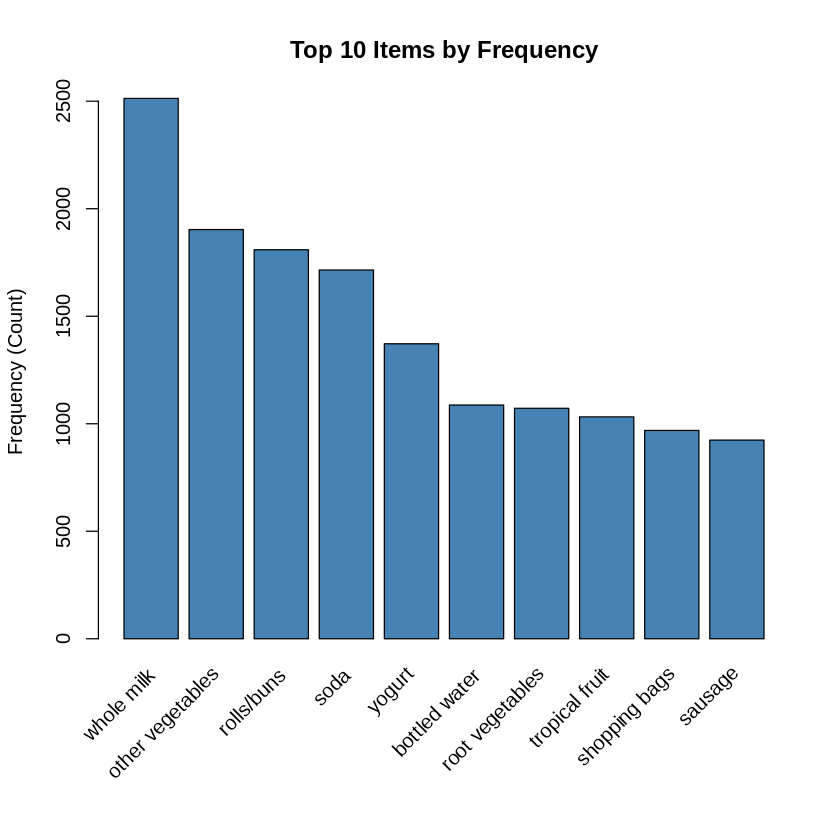

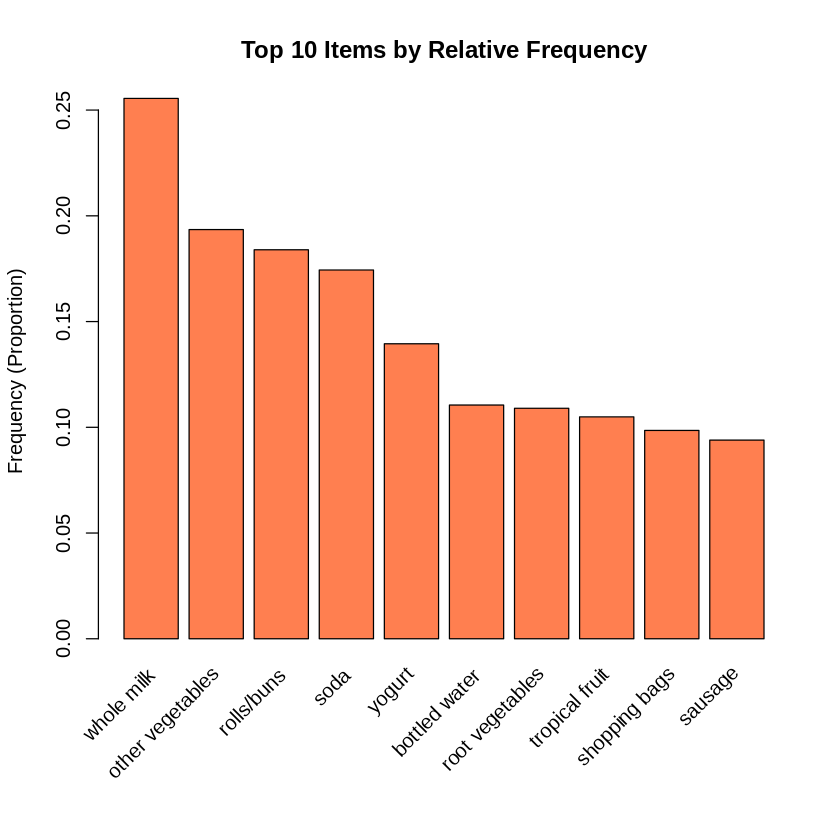

In [3]:
cat("\n===== Top 10 Most Frequent Items =====\n")
itemFrequencyPlot(Groceries,
                  topN  = 10,
                  type  = "absolute",
                  main  = "Top 10 Items by Frequency",
                  col   = "steelblue",
                  ylab  = "Frequency (Count)")

# Relative frequency plot
itemFrequencyPlot(Groceries,
                  topN  = 10,
                  type  = "relative",
                  main  = "Top 10 Items by Relative Frequency",
                  col   = "coral",
                  ylab  = "Frequency (Proportion)")

# 4. Apply Apriori Algorithm

In [4]:
# Parameters:
#   support    = 0.01  → item set appears in at least 1% of transactions
#   confidence = 0.25  → rule is correct at least 25% of the time
#   minlen     = 2     → at least 2 items per rule

cat("\n===== Running Apriori Algorithm =====\n")
rules <- apriori(Groceries,
                 parameter = list(supp     = 0.01,
                                  conf     = 0.25,
                                  minlen   = 2,
                                  maxlen   = 10))

cat("\n===== Rules Summary =====\n")
summary(rules)

cat("\n===== Top 10 Rules by Lift =====\n")
rules_sorted <- sort(rules, by = "lift", decreasing = TRUE)
inspect(head(rules_sorted, 10))


===== Running Apriori Algorithm =====
Apriori

Parameter specification:
 confidence minval smax arem  aval originalSupport maxtime support minlen
       0.25    0.1    1 none FALSE            TRUE       5    0.01      2
 maxlen target  ext
     10  rules TRUE

Algorithmic control:
 filter tree heap memopt load sort verbose
    0.1 TRUE TRUE  FALSE TRUE    2    TRUE

Absolute minimum support count: 98 

set item appearances ...[0 item(s)] done [0.00s].
set transactions ...[169 item(s), 9835 transaction(s)] done [0.00s].
sorting and recoding items ... [88 item(s)] done [0.00s].
creating transaction tree ... done [0.00s].
checking subsets of size 1 2 3 4 done [0.00s].
writing ... [170 rule(s)] done [0.00s].
creating S4 object  ... done [0.00s].

===== Rules Summary =====


set of 170 rules

rule length distribution (lhs + rhs):sizes
 2  3 
96 74 

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  2.000   2.000   2.000   2.435   3.000   3.000 

summary of quality measures:
    support          confidence        coverage            lift       
 Min.   :0.01007   Min.   :0.2517   Min.   :0.01729   Min.   :0.9932  
 1st Qu.:0.01159   1st Qu.:0.2973   1st Qu.:0.03101   1st Qu.:1.5215  
 Median :0.01454   Median :0.3587   Median :0.04291   Median :1.7784  
 Mean   :0.01822   Mean   :0.3703   Mean   :0.05187   Mean   :1.8747  
 3rd Qu.:0.02097   3rd Qu.:0.4253   3rd Qu.:0.05857   3rd Qu.:2.1453  
 Max.   :0.07483   Max.   :0.5862   Max.   :0.25552   Max.   :3.2950  
     count      
 Min.   : 99.0  
 1st Qu.:114.0  
 Median :143.0  
 Mean   :179.2  
 3rd Qu.:206.2  
 Max.   :736.0  

mining info:
      data ntransactions support confidence
 Groceries          9835    0.01       0.25
                                                                              


===== Top 10 Rules by Lift =====
     lhs                                   rhs                support   
[1]  {citrus fruit, other vegetables}   => {root vegetables}  0.01037112
[2]  {tropical fruit, other vegetables} => {root vegetables}  0.01230300
[3]  {beef}                             => {root vegetables}  0.01738688
[4]  {citrus fruit, root vegetables}    => {other vegetables} 0.01037112
[5]  {tropical fruit, root vegetables}  => {other vegetables} 0.01230300
[6]  {other vegetables, whole milk}     => {root vegetables}  0.02318251
[7]  {whole milk, curd}                 => {yogurt}           0.01006609
[8]  {other vegetables, yogurt}         => {root vegetables}  0.01291307
[9]  {other vegetables, yogurt}         => {tropical fruit}   0.01230300
[10] {other vegetables, rolls/buns}     => {root vegetables}  0.01220132
     confidence coverage   lift     count
[1]  0.3591549  0.02887646 3.295045 102  
[2]  0.3427762  0.03589222 3.144780 121  
[3]  0.3313953  0.05246568 3.040367 1

# 5. Filter Rules

In [5]:
# Rules with high confidence
high_conf_rules <- subset(rules, confidence > 0.5)
cat("\n===== Rules with Confidence > 0.5 =====\n")
cat("Number of rules:", length(high_conf_rules), "\n")
inspect(head(sort(high_conf_rules, by = "lift"), 5))

# Rules for a specific item (e.g., whole milk)
milk_rules <- subset(rules, rhs %in% "whole milk")
cat("\n===== Rules with 'whole milk' on RHS =====\n")
inspect(head(sort(milk_rules, by = "lift"), 5))


===== Rules with Confidence > 0.5 =====
Number of rules: 14 
    lhs                                  rhs                support   
[1] {citrus fruit, root vegetables}   => {other vegetables} 0.01037112
[2] {tropical fruit, root vegetables} => {other vegetables} 0.01230300
[3] {root vegetables, rolls/buns}     => {other vegetables} 0.01220132
[4] {curd, yogurt}                    => {whole milk}       0.01006609
[5] {other vegetables, butter}        => {whole milk}       0.01148958
    confidence coverage   lift     count
[1] 0.5862069  0.01769192 3.029608 102  
[2] 0.5845411  0.02104728 3.020999 121  
[3] 0.5020921  0.02430097 2.594890 120  
[4] 0.5823529  0.01728521 2.279125  99  
[5] 0.5736041  0.02003050 2.244885 113  

===== Rules with 'whole milk' on RHS =====
    lhs                                  rhs          support    confidence
[1] {curd, yogurt}                    => {whole milk} 0.01006609 0.5823529 
[2] {other vegetables, butter}        => {whole milk} 0.01148958 0.573

# 6. Parameters: Support, Confidence, Lift

In [6]:
cat("\n===== Quality Measures of Top 10 Rules =====\n")
quality_df <- as.data.frame(quality(head(rules_sorted, 10)))
quality_df$rule <- labels(head(rules_sorted, 10))
print(quality_df[, c("rule", "support", "confidence", "lift")])


===== Quality Measures of Top 10 Rules =====
                                                      rule    support
118   {citrus fruit,other vegetables} => {root vegetables} 0.01037112
128 {tropical fruit,other vegetables} => {root vegetables} 0.01230300
40                             {beef} => {root vegetables} 0.01738688
117   {citrus fruit,root vegetables} => {other vegetables} 0.01037112
127 {tropical fruit,root vegetables} => {other vegetables} 0.01230300
155     {other vegetables,whole milk} => {root vegetables} 0.02318251
98                           {whole milk,curd} => {yogurt} 0.01006609
144         {other vegetables,yogurt} => {root vegetables} 0.01291307
134          {other vegetables,yogurt} => {tropical fruit} 0.01230300
150     {other vegetables,rolls/buns} => {root vegetables} 0.01220132
    confidence     lift
118  0.3591549 3.295045
128  0.3427762 3.144780
40   0.3313953 3.040367
117  0.5862069 3.029608
127  0.5845411 3.020999
155  0.3097826 2.842082
98   0.3852140 2

# 7. Visualizations using arulesViz

To reduce overplotting, jitter is added! Use jitter = 0 to prevent jitter.

To reduce overplotting, jitter is added! Use jitter = 0 to prevent jitter.



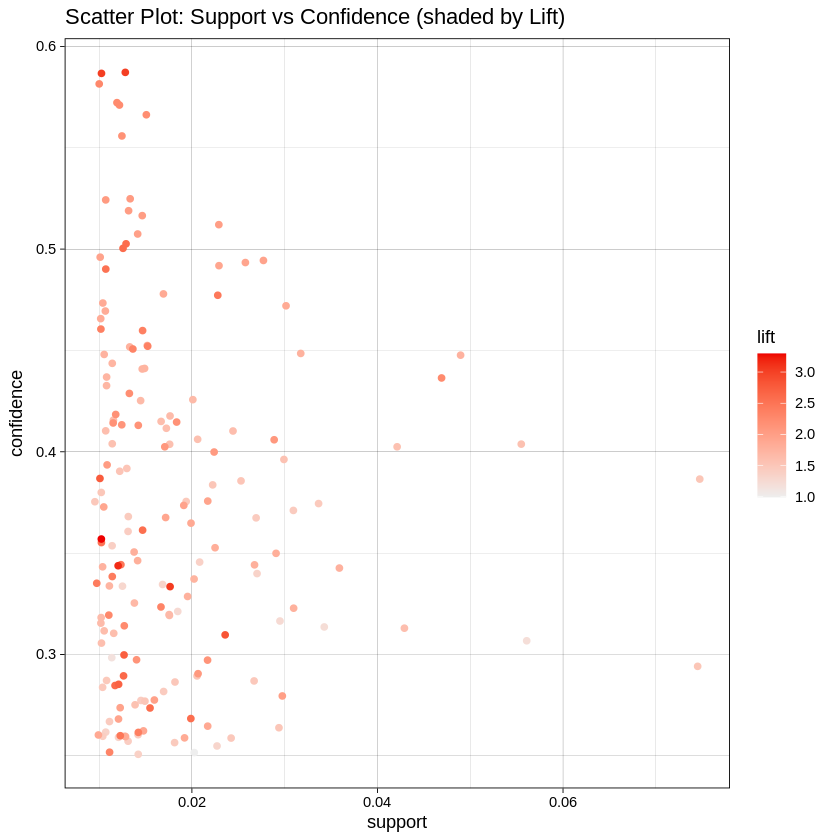

HTML widgets cannot be represented in plain text (need html)

Warning message:
“Unknown control parameters: main”


Available control parameters (with default values):
k	 =  20
aggr.fun	 =  function (x, ...)  UseMethod("mean")
rhs_max	 =  10
lhs_label_items	 =  2
col	 =  c("#EE0000FF", "#EEEEEEFF")
groups	 =  NULL
engine	 =  ggplot2
verbose	 =  FALSE


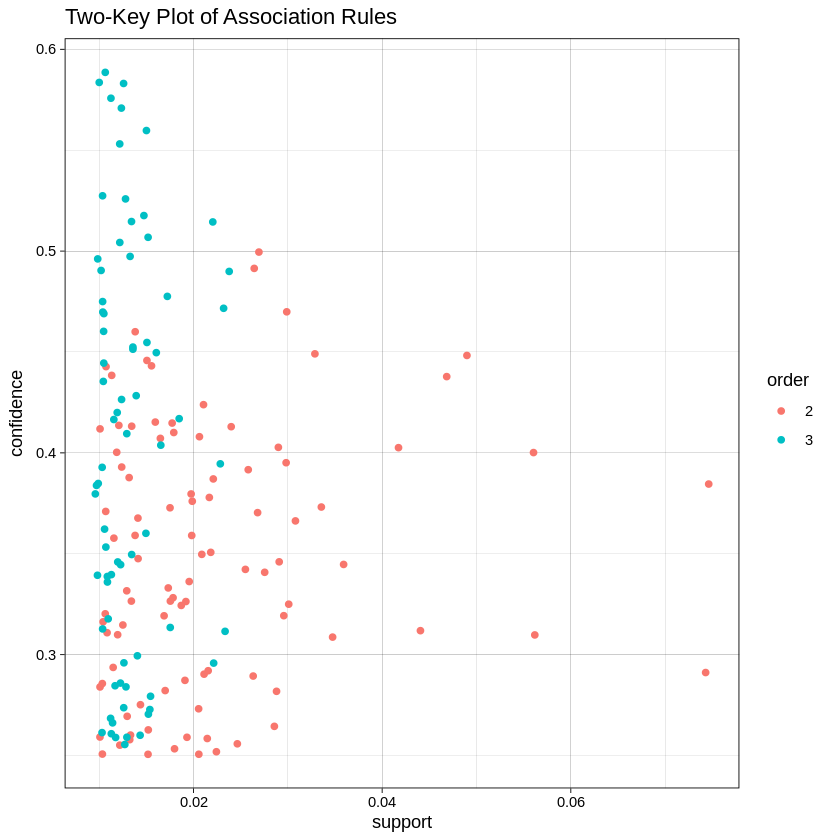

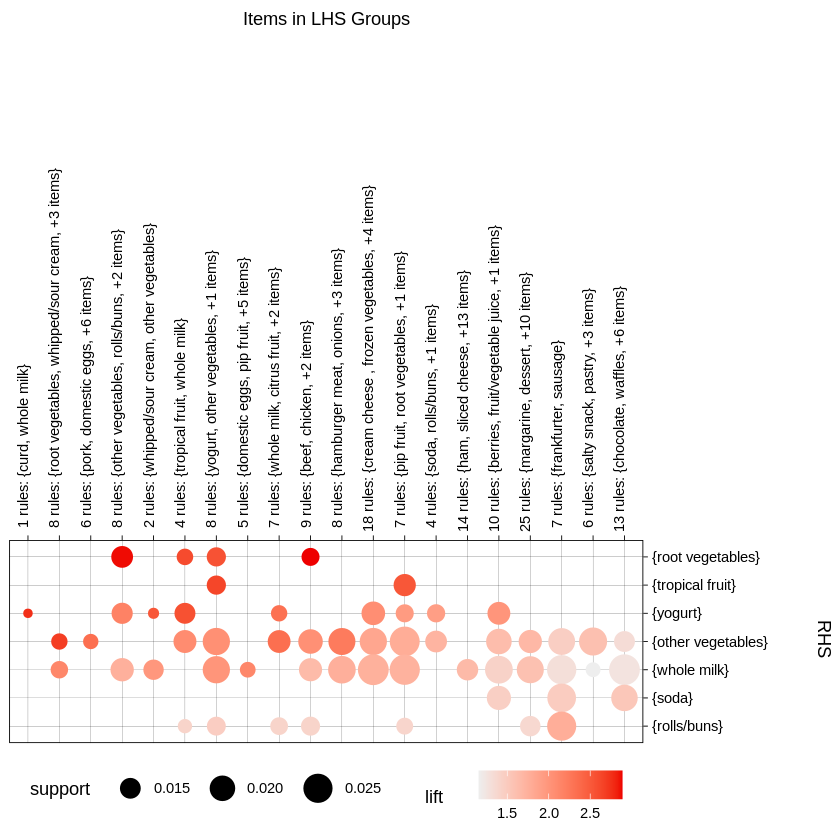

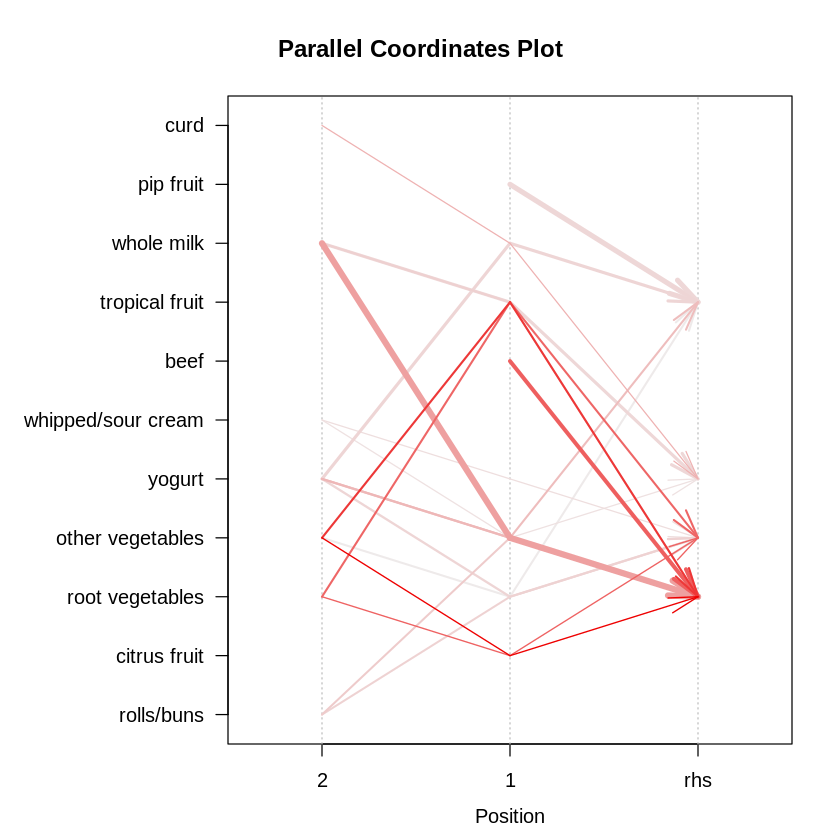

In [7]:
# Plot 1: Scatter plot – support vs confidence coloured by lift
plot(rules,
     method  = "scatterplot",
     measure  = c("support", "confidence"),
     shading  = "lift",
     main     = "Scatter Plot: Support vs Confidence (shaded by Lift)")

# Plot 2: Two-key plot
plot(rules,
     method = "two-key plot",
     main   = "Two-Key Plot of Association Rules")

# Plot 3: Graph-based visualization (top 10 rules)
plot(head(sort(rules, by = "lift"), 10),
     method = "graph",
     engine = "htmlwidget")

# Plot 4: Matrix grouped visualization
plot(rules,
     method = "grouped matrix",
     main   = "Grouped Matrix of Association Rules")

# Plot 5: Parallel coordinates plot
plot(head(sort(rules, by = "lift"), 20),
     method = "paracoord",
     main   = "Parallel Coordinates Plot")

# 8. Save Rules to CSV

In [8]:
rules_df <- as(rules, "data.frame")
write.csv(rules_df, "association_rules.csv", row.names = FALSE)
cat("\nRules saved to association_rules.csv\n")


Rules saved to association_rules.csv
